In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/code/compositional`


In [2]:
using DataFrames, JLD2, StatsBase
using CSV, CodecZlib, LaTeXStrings
using CairoMakie, MakiePublication

In [3]:
include("./utils.jl")
using .Utils

In [4]:
# Set theme for plots
__theme = MakiePublication.theme_acs(; ishollowmarkers=[true,true])
set_theme!(__theme)

In [6]:
# Root that contains domains
root = "./Data/arx_sources"

# domain -> topic -> samples (each sample = Vector{String} lines)
domains = Dict{String, Dict{String, Vector{Vector{String}}}}()

for domain_dir in filter(isdir, readdir(root; join=true))
    domain = splitpath(domain_dir)[end]
    topic_map = Dict{String, Vector{Vector{String}}}()

    for topic_dir in filter(isdir, readdir(domain_dir; join=true))
        topic = splitpath(topic_dir)[end]
        texts_dir = joinpath(topic_dir, "texts")
        if !isdir(texts_dir); continue; end

        txt_files = filter(f -> endswith(f, ".txt"), readdir(texts_dir; join=true))
        if isempty(txt_files); continue; end

        topic_map[topic] = [readlines(f) for f in txt_files]
    end

    if !isempty(topic_map)
        domains[domain] = topic_map
    end
end


Domains are: **astro-ph**, **hep**, **nucl**, **math**

In [7]:
# Create a DataFrame with words counts for all domains and topics
df = DataFrame(
    domain = String[],
    env = String[],
    species_id = String[],
    sample_id = Int[],
    count = Int[],
    nreads = Int[]
)

for (domain, topics) in domains
    for (topic, samples) in topics
        for (i,sample) in enumerate(samples)
            # Clean each word: keep only letters/numbers
            clean_sample = [replace(w, r"^[^A-Za-z0-9]+|[^A-Za-z0-9]+$" => "") for w in sample]
            
            # Remove empty or short words
            clean_sample = filter(!isempty, clean_sample)
        
            # Count words
            cnt_map = countmap(clean_sample)
            for (k,v) in cnt_map
                push!(df, (domain, topic, k, i, v, sum(values(cnt_map))))
            end
        end
    end
end

# Remove stopwords
STOPWORDS = Set([
    "me","my","myself","we","our","ours","ourselves","you","your","yours","yourself","yourselves","he","him","his","himself",
    "she","her","hers","herself","it","its","itself","hey","them","their","theirs","themselves","what","which","who","whom",
    "this","that","these","those","am","is","are","was","were","be","been","being","have","has","had","having","do","does","did",
    "doing","an","the","and","but","if","or","because","as","until","while","of","at","by","for","with","about","against","between",
    "into","through","during","before","after","above","below","to","from","up","down","in","out","on","off","over","under","again",
    "further","then","once","here","there","when","where","why","how","all","any","both","each","few","more","most","other","some",
    "such","no","nor","not","only","own","same","so","than","too","very","can","will","just","don","should","now",
    "a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v", "w","x","y","z"
])

filter!(row -> !(row.species_id in STOPWORDS), df);

In [8]:
# Create different dfs for the different scales
agg0 = deepcopy(df)
agg0.env .= agg0.domain .* "-" .* agg0.env
select!(agg0, [:env, :species_id, :sample_id, :count, :nreads])

agg1 = select(df, [:domain, :species_id, :sample_id, :count, :nreads])
rename!(agg1, :domain => :env)

agg2 = select(df, [:species_id, :sample_id, :count, :nreads])
agg2.env .= "Math&Physics";

In [17]:
df = deepcopy(agg1)
Utils.df_filter!(df; min_samples=5e1, min_nreads=5e3)

println("--- AFD ---")
afd = Utils.compute_AFD(df; occ=0.99, bins=30, plot=false, verbose=true, save=false);

--- AFD ---
Math&Physics


In [18]:
function gamma_params(df; occ=0.99)
    freqs = Utils.get_frequencies(df; occ = occ, rescale=false)
    μv = mean(freqs, dims=1)
    σv = std(freqs, dims=1)
    βv = μv .^ 2 ./ σv .^ 2
    return mean(βv), std(βv)
end

function betap_params(df; occ=0.99)
    freqs = Utils.get_frequencies(df; occ = occ, rescale=false)
    μv = mean(freqs, dims=1)
    σv = std(freqs, dims=1)
    θ = mean(μv) # THIS IS AN ANSATZ
    βv = μv .^ 2 ./ σv .^ 2 .+ μv .* θ ./ σv .^ 2 .+ 2
    αv = μv .^ 3 ./ σv .^ 2 ./ θ .+ μv .^ 2 ./ σv .^ 2 .+ μv ./ θ
    return mean(αv), std(αv), mean(βv), std(βv)
end

betap_params (generic function with 1 method)

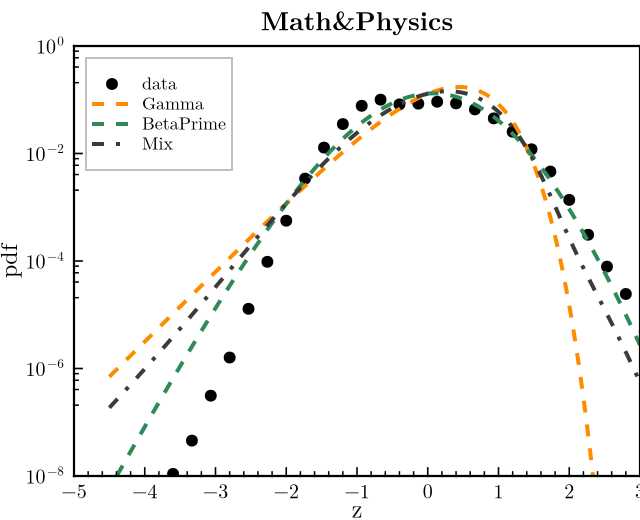

In [19]:
# Plot AFDs

# Collect environment names in a robust way
envs = afd isa AbstractDict ? collect(keys(afd)) : [e for (e, _) in afd]
nenv  = length(envs)

ncols = 4
if nenv == 1
    ncols =1
end
nrows = cld(nenv, ncols)            # ceil division
fig   = Figure(size=(320*ncols, 260*nrows))

# Global axis settings
xlims = (-5, 3)
ylims = (1e-8, 1e0)
zrange = -4.5:1e-2:3.5

residuals = Dict()
for (i, e) in enumerate(envs)
    row = (i - 1) ÷ ncols + 1
    col = (i - 1) % ncols + 1
    ax = Axis(fig[row, col];
        title = string(e),
        yscale = log10,
        limits = (xlims, ylims),
        xlabel = L"\text{z}",
        ylabel = L"\text{pdf}",
        xlabelsize = 12, ylabelsize = 12, titlesize = 13,
        xticklabelsize = 10, yticklabelsize = 10
    )

    # Data for this environment
    x, y = afd isa AbstractDict ? afd[e] : only(last.(filter(p -> first(p) == e, afd)))

    # Parameters for this environment
    k, sk = gamma_params(df[df.env .== e, :], occ=0.99)
    α, sα, β, sβ = betap_params(df[df.env .== e, :], occ=0.99)

    # Plots
    scatter!(ax, x, 10 .^ log.(y); markersize=7, label="data", color=:black)

    lines!(ax, zrange, 10 .^ Utils.lr_gamma(zrange, k);
           linewidth=2, linestyle=:dash, label="Gamma", color=:darkorange)
    
    lines!(ax, zrange, 10 .^ Utils.lr_betap(zrange, α, β);
           linewidth=2, linestyle=:dash, label="BetaPrime", color=:seagreen)

    lines!(ax, zrange, 10 .^ Utils.lr_gam_bp_mix(zrange, k, α, β);
           linewidth=2, linestyle=:dashdot, label="Mix", color=:gray23)
    # Legend inside each axis
    axislegend(ax; position=:lt, framevisible=true, labelsize=9, padding=3)
end

# Optional: tighten layout a bit
colgap!(fig.layout, 12)
rowgap!(fig.layout, 10)

fig


In [20]:
# Analysis of residuals
envs = afd isa AbstractDict ? collect(keys(afd)) : [e for (e, _) in afd]

residuals = Dict()
for (i, e) in enumerate(envs)
    
    residuals[e] = Dict()
    
    x, y = afd isa AbstractDict ? afd[e] : only(last.(filter(p -> first(p) == e, afd)))
    
    k, sk = gamma_params(df[df.env .== e, :], occ=0.99)
    α, sα, β, sβ = betap_params(df[df.env .== e, :], occ=0.99)

    residuals[e]["g"] = (x, y .- exp.(Utils.lr_gamma(x, k)))
    residuals[e]["bp"] = (x, y .- exp.(Utils.lr_betap(x, α, β)))
    residuals[e]["m"] = (x, y .- exp.(Utils.lr_gam_bp_mix(x, k, α, β)))
end